In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

In [57]:
KLIFS = pd.read_csv('../../source_data/16_KLIFS/KLIFS_compiled.csv')
#KLIFS = KLIFS[KLIFS['KLIFS_idx']!='linker:50'].reset_index(drop=True)
library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')

SAV_ABE1 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool1.zip')
SAV_ABE1 = pd.merge(SAV_ABE1, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE1 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool1.zip')
SAV_CBE1 = pd.merge(SAV_CBE1, library[['gRNA_id', 'Gene']], on='gRNA_id')


SAV_ABE2 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool2.zip')
SAV_ABE2 = pd.merge(SAV_ABE2, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE2 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool2.zip')
SAV_CBE2 = pd.merge(SAV_CBE2, library[['gRNA_id', 'Gene']], on='gRNA_id')

#and remove WT
SAV_ABE1 = SAV_ABE1[SAV_ABE1['HGVSp']!='WT']
SAV_ABE2 = SAV_ABE2[SAV_ABE2['HGVSp']!='WT']
SAV_CBE1 = SAV_CBE1[SAV_CBE1['HGVSp']!='WT']
SAV_CBE2 = SAV_CBE2[SAV_CBE2['HGVSp']!='WT']

In [94]:
def rg_dict_gen(SAV_ABE2, SAV_CBE2, genes, min_edit):

    SAV_ABE2['Codon'] = [int(i) for i in SAV_ABE2['Codon']]
    SAV_CBE2['Codon'] = [int(i) for i in SAV_CBE2['Codon']]

    #first CBE
    rg_CBE = []
    for gene in genes:
        pocket = list(KLIFS[gene])

        relevant_guides = []
        for residue in pocket:
            subset = SAV_CBE2[(SAV_CBE2['Gene']==gene) & (SAV_CBE2['Codon']==residue) & (SAV_CBE2['%Reads']>=min_edit)]
            relevant_guides.append(list(subset['gRNA_id']))
        
        rg_CBE.append(relevant_guides)

    #then ABE
    rg_ABE = []
    for gene in genes:
        pocket = list(KLIFS[gene])

        relevant_guides = []
        for residue in pocket:
            subset = SAV_ABE2[(SAV_ABE2['Gene']==gene) & (SAV_ABE2['Codon']==residue) & (SAV_ABE2['%Reads']>=min_edit)]
            relevant_guides.append(list(subset['gRNA_id']))
        
        rg_ABE.append(relevant_guides)

    CBE_rg_dict = dict(zip(genes, rg_CBE))
    ABE_rg_dict = dict(zip(genes, rg_ABE))

    return CBE_rg_dict, ABE_rg_dict

from matplotlib.patches import Rectangle

def finger_plotv3(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition):

    #add coloring depending on if LFC >0 or LFC<0

    KLIFS2 = KLIFS.copy()

    #genes = ['CDK12', 'CDK13']

    for gene in genes:
        c = CBE_rg_dict[gene]
        a = ABE_rg_dict[gene]

        for i, val in KLIFS2.iterrows():
            nn = val[gene]
            try:
                subset_ABE = list(ABE_s2[ABE_s2['gRNA_id'].isin(a[i])][f'LFC_median_ABE_{condition}'])
                subset_CBE = list(CBE_s2[CBE_s2['gRNA_id'].isin(c[i])][f'LFC_median_CBE_{condition}'])

                #num_sig_ABE = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_ABE_{condition}']<FDR_cutoff)])
                #num_sig_CBE = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_CBE_{condition}']<FDR_cutoff)])

                num_sig_ABE_up = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_ABE_{condition}']<FDR_cutoff) & (ABE_s2[f'LFC_median_ABE_{condition}']>0)])
                num_sig_CBE_up = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_CBE_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_CBE_{condition}']>0)])
                num_sig_ABE_down = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_ABE_{condition}']<FDR_cutoff)& (ABE_s2[f'LFC_median_ABE_{condition}']<0)])
                num_sig_CBE_down = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_CBE_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_CBE_{condition}']<0)])
        
            except:
                subset_ABE = list(ABE_s2[ABE_s2['gRNA_id'].isin(a[i])][f'LFC_median_{condition}'])
                subset_CBE = list(CBE_s2[CBE_s2['gRNA_id'].isin(c[i])][f'LFC_median_{condition}'])

                num_sig_ABE_up = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_{condition}']<FDR_cutoff) & (ABE_s2[f'LFC_median_{condition}']>0)])
                num_sig_CBE_up = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_{condition}']>0)])
                num_sig_ABE_down = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_{condition}']<FDR_cutoff)& (ABE_s2[f'LFC_median_{condition}']<0)])
                num_sig_CBE_down = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_{condition}']<0)])


            total_sig_up = num_sig_ABE_up + num_sig_CBE_up
            total_sig_down = num_sig_ABE_down + num_sig_CBE_down
            comb1 = subset_ABE + subset_CBE

            KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_guides'] = len(comb1)
            KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_avg'] = np.average(comb1)
            KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_num_sig_up'] = total_sig_up
            KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_num_sig_down'] = total_sig_down
    
    #k2 = KLIFS2[['CDK12_guides', 'CDK12_avg', 'CDK13_guides', 'CDK13_avg']]

    for gene in genes:
        KLIFS2[gene] = KLIFS2[f'{gene}_avg']/KLIFS2[f'{gene}_guides']

    plotting2 = KLIFS2[genes].T

    fig, ax = plt.subplots(figsize=(20,3))
    sns.heatmap(plotting2, cmap='seismic', center=0, ax=ax, linewidth=0.5)
    ax.set_facecolor('grey')


    for idx1, gene in enumerate(genes):
        
        sig_up = list(KLIFS2[f'{gene}_num_sig_up']>0)
        sig_down = list(KLIFS2[f'{gene}_num_sig_down']>0)

        for idx, i in enumerate(sig_up):
            if i==True:
                if sig_down[idx]==True:
                    ax.add_patch(Rectangle((idx,idx1), 1, 1, ec='purple', fc='none', lw=1, hatch='///'))
                elif sig_down[idx]==False:
                    ax.add_patch(Rectangle((idx,idx1), 1, 1, ec='red', fc='none', lw=1, hatch='///'))

            elif i==False:
                if sig_down[idx]==True:
                    ax.add_patch(Rectangle((idx,idx1), 1, 1, ec='blue', fc='none', lw=1, hatch='///'))


    #ax.set_xticks(range(85))
    ax.set_xticklabels(range(1,86))

    ax.set_title(f'{condition}', fontsize=12)
    fig.tight_layout()

    return plotting2, fig

In [60]:
ABE_s1_plasmid = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/ABE_subpool1_barcode_Plasmid_base.csv')
CBE_s1_plasmid = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CBE_subpool1_barcode_Plasmid_base.csv')

ABE_s2_plasmid = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CDK12_13_ABE_barcode_Plasmid_base.csv')
CBE_s2_plasmid = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CDK12_13_CBE_barcode_Plasmid_base.csv')

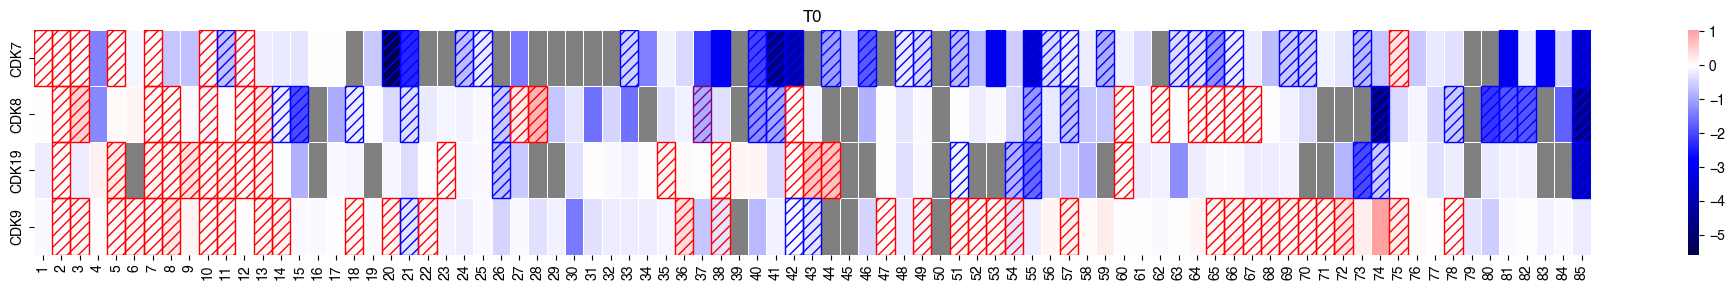

In [ ]:
min_base_counts = 100
FDR_cutoff = 0.1
ABE_s1 = ABE_s1_plasmid[ABE_s1_plasmid['base_RAW']>=min_base_counts]
CBE_s1 = CBE_s1_plasmid[CBE_s1_plasmid['base_RAW']>=min_base_counts]

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']
min_edit = 10

CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE1, SAV_CBE1, genes, min_edit)

condition = 'T0'
plotting_a, fig = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

#fig.savefig('../../figures/T0_subpool1.pdf', transparent=False)

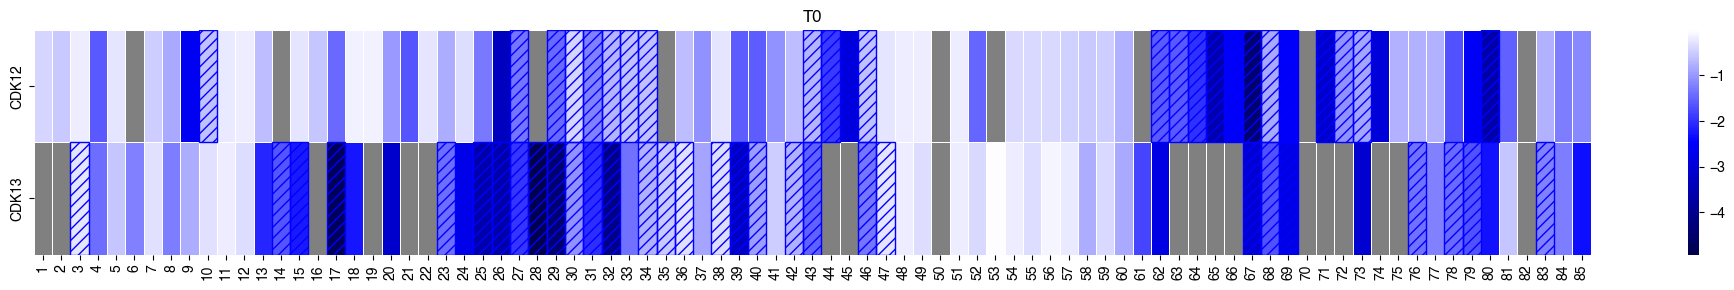

In [ ]:
min_base_counts = 100
FDR_cutoff = 0.1
ABE_s2 = ABE_s2_plasmid[ABE_s2_plasmid['base_RAW']>=min_base_counts]
CBE_s2 = CBE_s2_plasmid[CBE_s2_plasmid['base_RAW']>=min_base_counts]

genes = ['CDK12', 'CDK13']
min_edit = 10

CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE2, SAV_CBE2, genes, min_edit)

condition = 'T0'
plotting_a, fig = finger_plotv3(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
#fig.savefig('../../figures/T0_subpool2.pdf', transparent=False)

In [49]:
ABE_s1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/ABE_subpool1_barcode_DMSO_base.csv')
CBE_s1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CBE_subpool1_barcode_DMSO_base.csv')

ABE_s2 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_ABE_barcode_DMSO_base.csv')
CBE_s2 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_CBE_barcode_DMSO_base.csv')

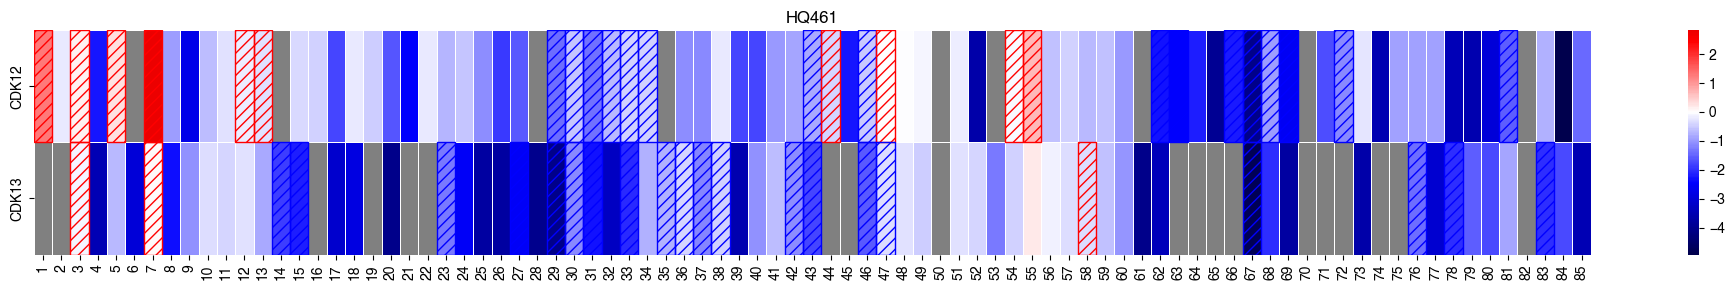

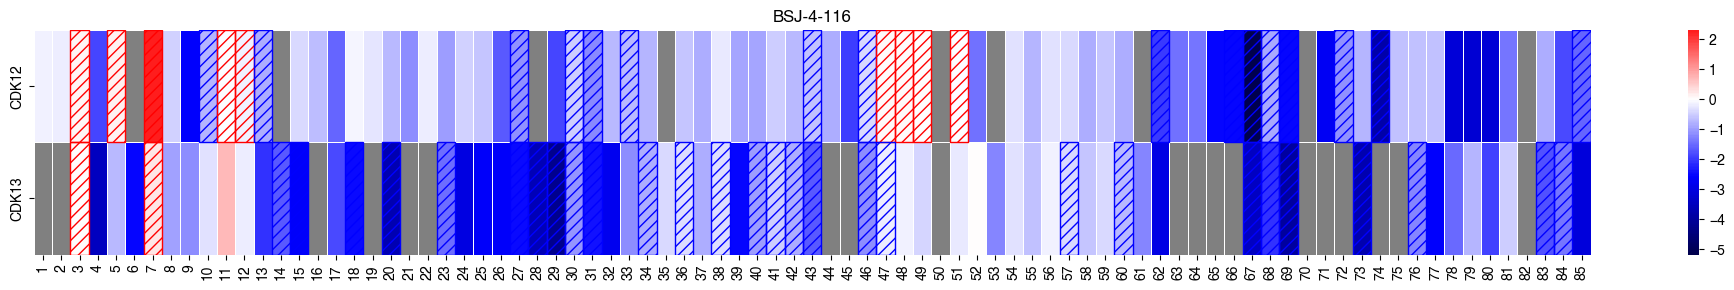

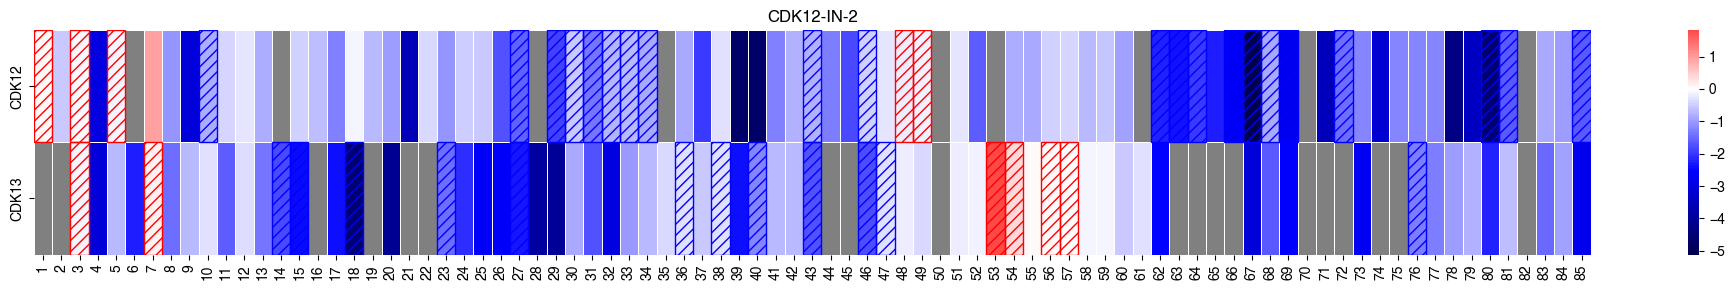

In [177]:
min_base_counts = 100
FDR_cutoff = 0.1
ABE_s2 = ABE_s2[ABE_s2['base_RAW']>=min_base_counts]
CBE_s2 = CBE_s2[CBE_s2['base_RAW']>=min_base_counts]

genes = ['CDK12', 'CDK13']
min_edit = 10

CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE2, SAV_CBE2, genes, min_edit)

condition = 'HQ461'
plotting_b, fig = finger_plotv3(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
#fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)


condition = 'BSJ-4-116'
plotting_c, fig = finger_plotv3(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
#fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

condition = 'CDK12-IN-2'
plotting_d, fig = finger_plotv3(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
#fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)


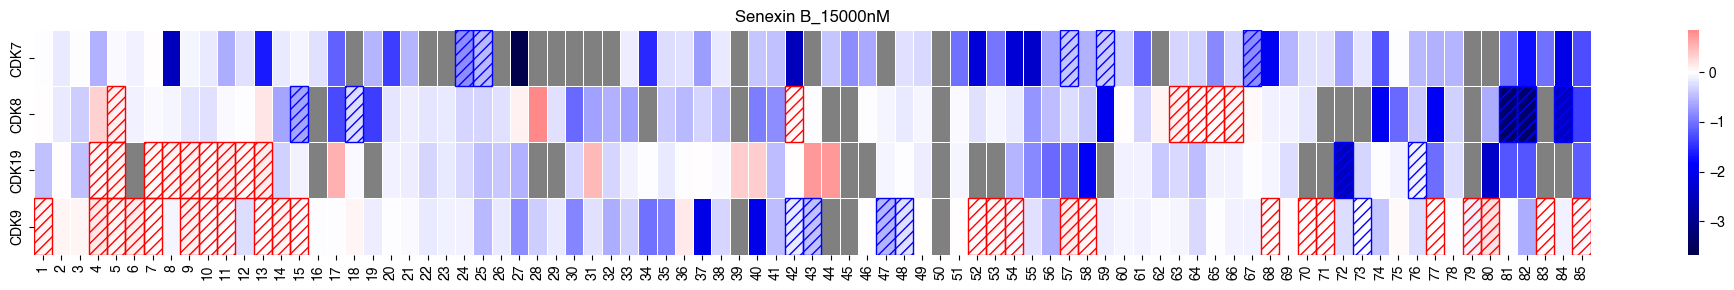

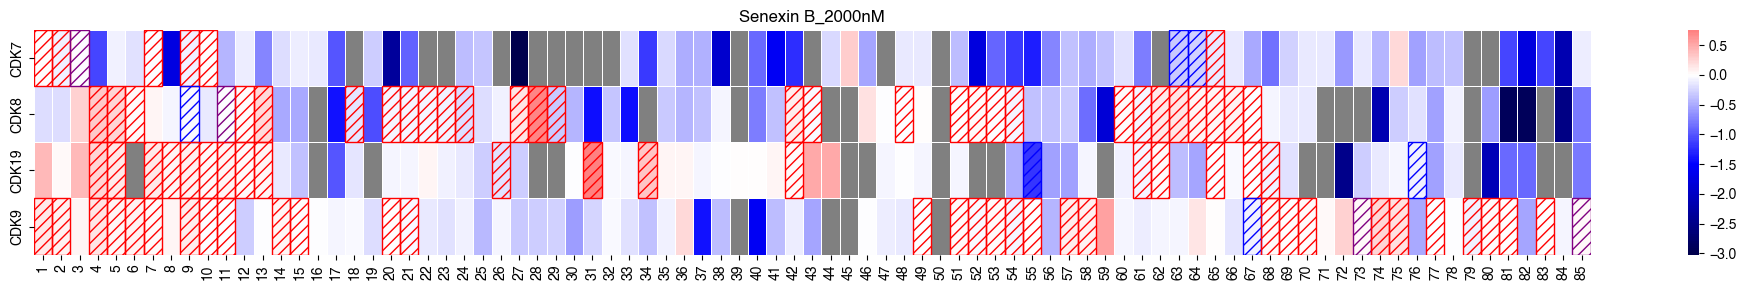

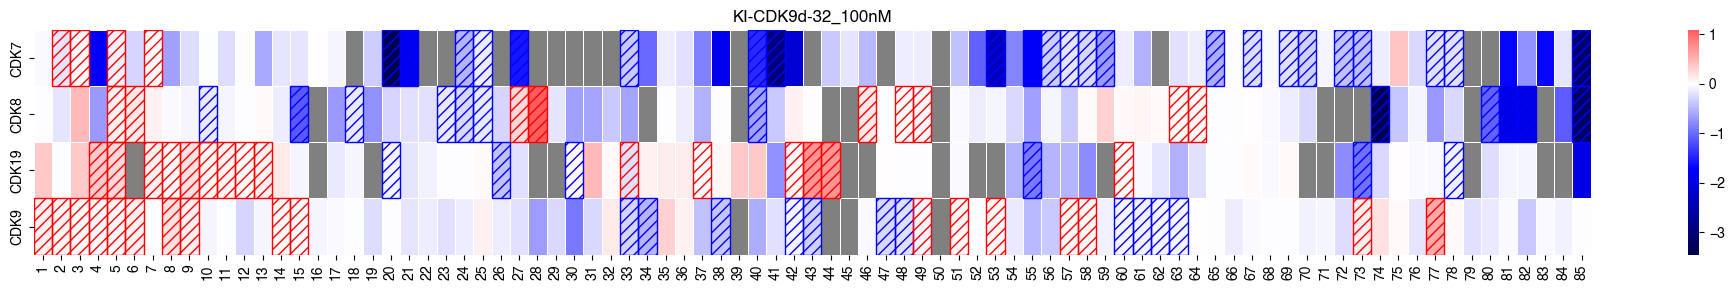

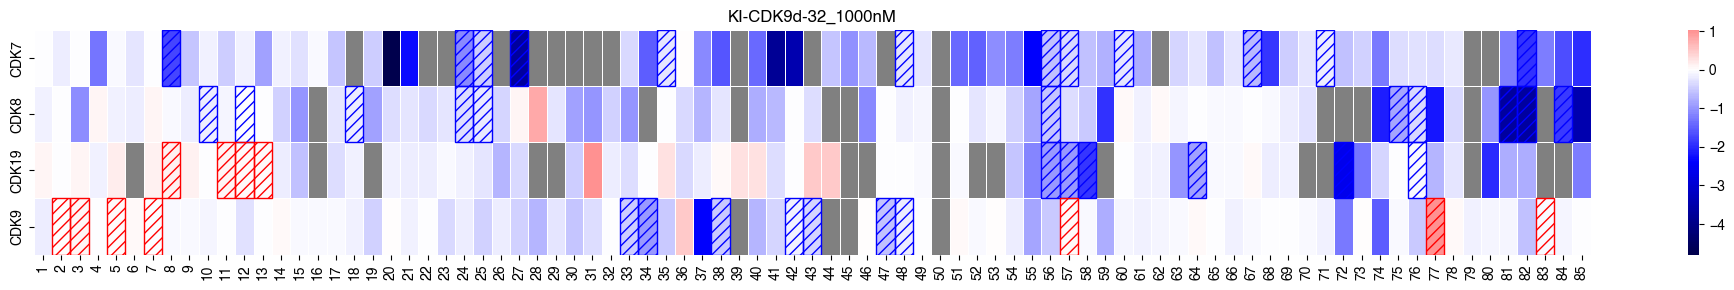

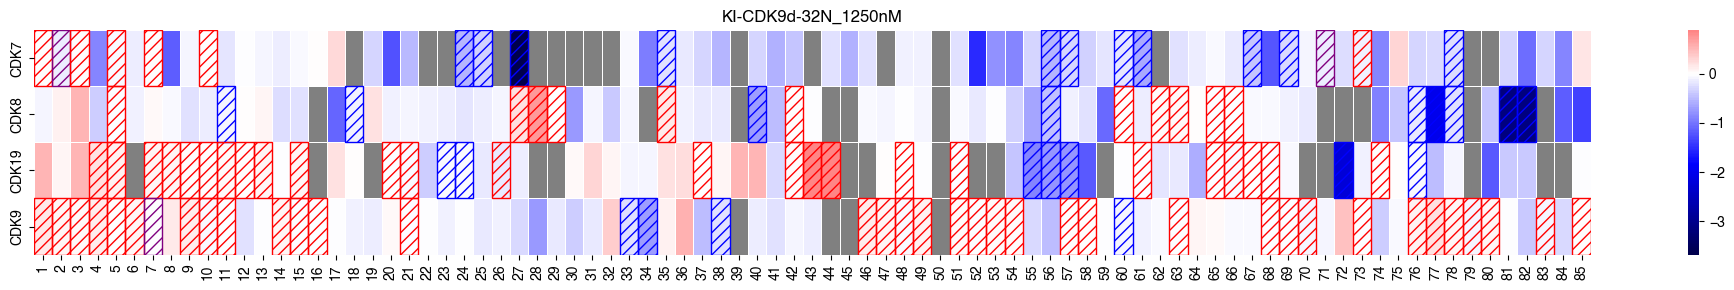

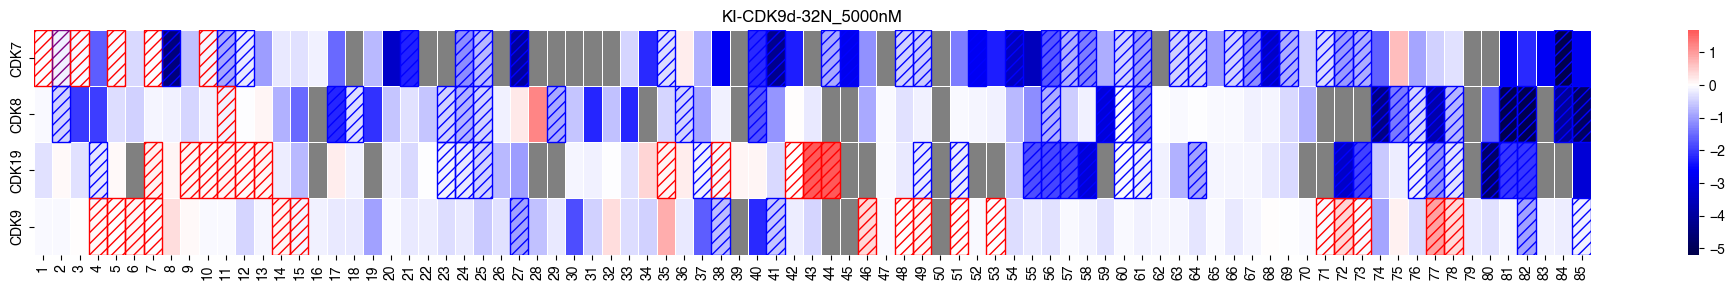

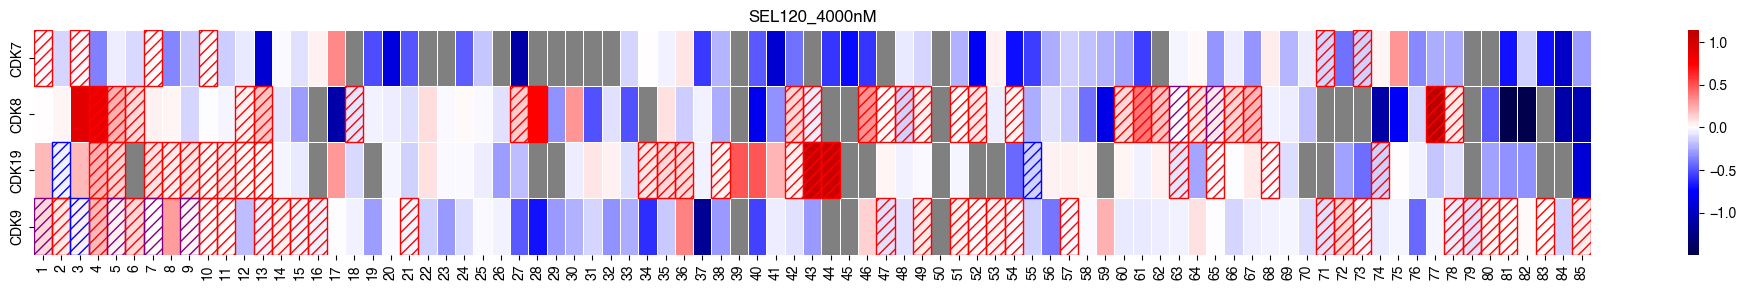

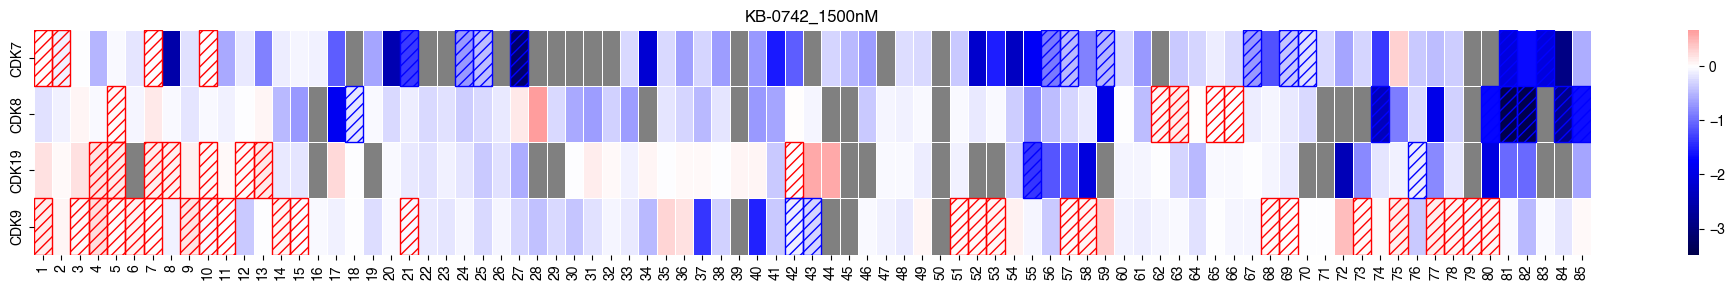

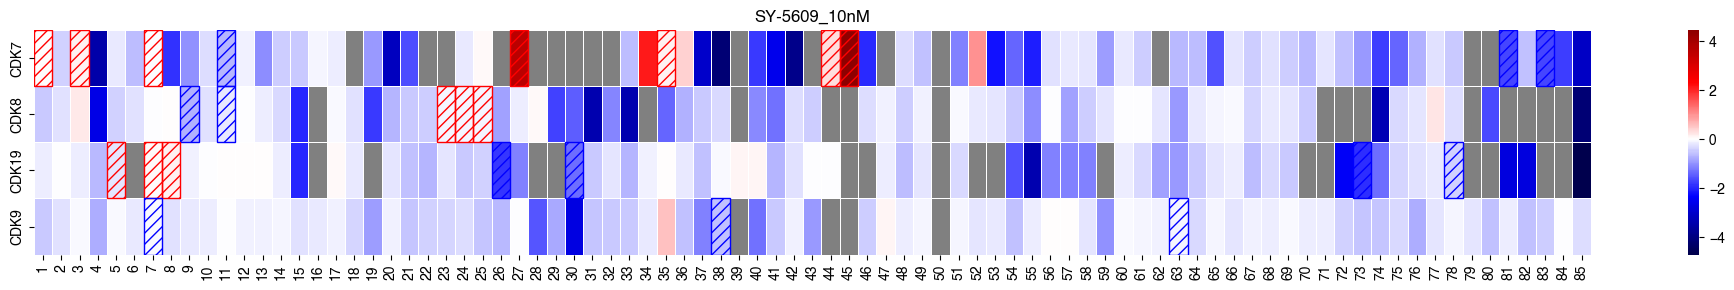

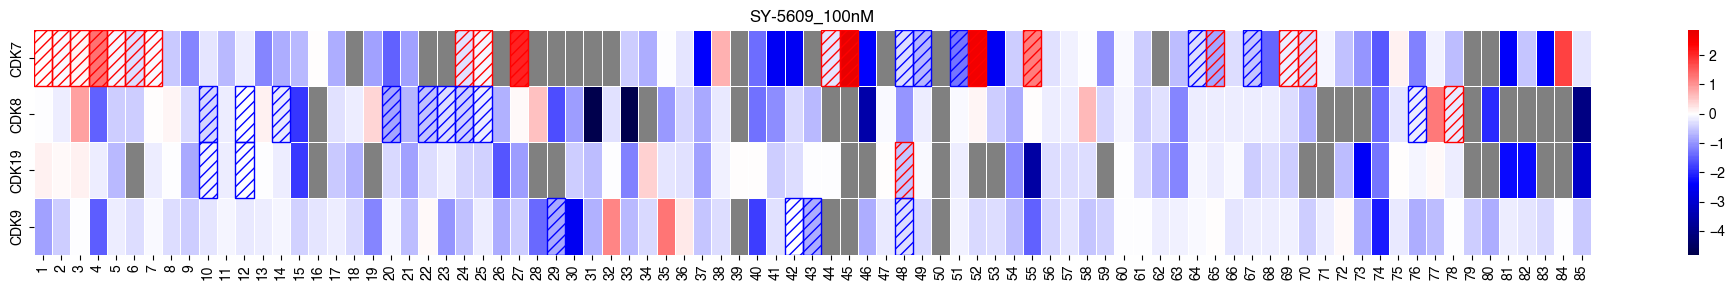

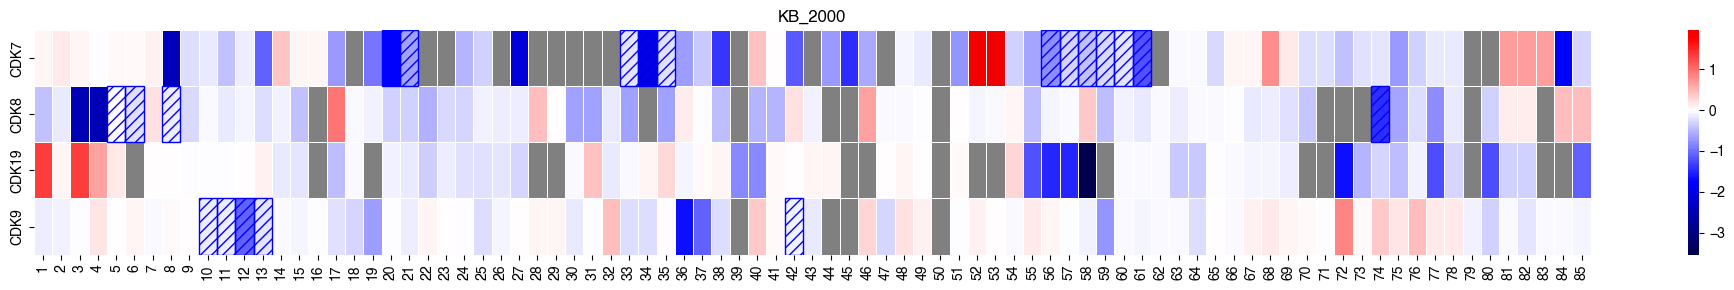

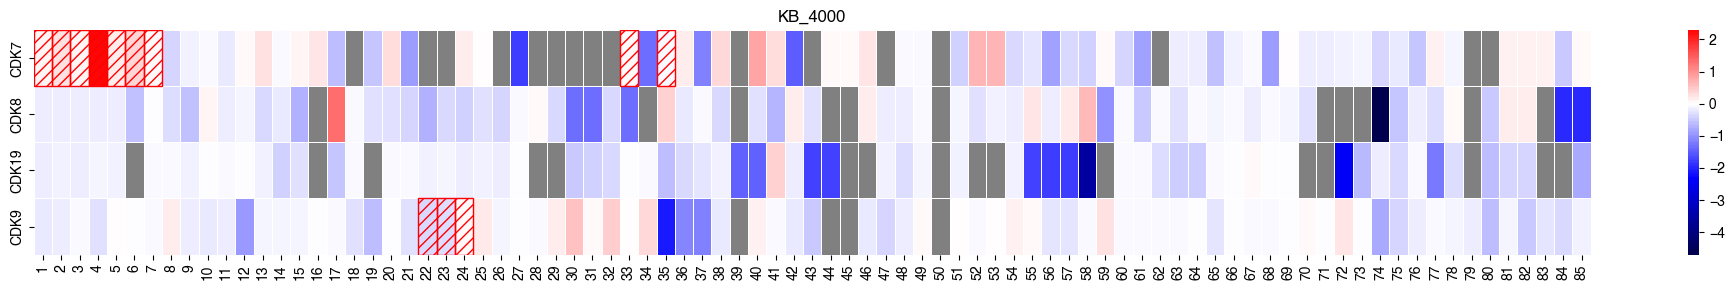

In [380]:
min_base_counts = 100
FDR_cutoff = 0.1
ABE_s1 = ABE_s1[ABE_s1['base_RAW']>=min_base_counts]
CBE_s1 = CBE_s1[CBE_s1['base_RAW']>=min_base_counts]

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']

CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE1, SAV_CBE1, genes, min_edit)


condition = 'Senexin B_15000nM'
plotting_a, fig = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
#fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

condition = 'Senexin B_2000nM'
plotting_b, fig = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
#fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

condition = 'KI-CDK9d-32_100nM'
plotting_c, fig = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
#fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

condition = 'KI-CDK9d-32_1000nM'
plotting_d, fig = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
#fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

condition = 'KI-CDK9d-32N_1250nM'
plotting_e, fig = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
#fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

condition = 'KI-CDK9d-32N_5000nM'
plotting_f, fig = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
#fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

condition = 'SEL120_4000nM'
plotting_g, fig = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
#fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

condition = 'KB-0742_1500nM'
plotting_gg, fig = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
#fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

#--------SY-------
ABE_sy = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/SY_5609_ABE_barcode_DMSO_base.csv')
CBE_sy = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/SY_5609_CBE_barcode_DMSO_base.csv')
ABE_sy = ABE_sy[ABE_sy['base_RAW']>=min_base_counts]
CBE_sy = CBE_sy[CBE_sy['base_RAW']>=min_base_counts]

condition = 'SY-5609_10nM'
plotting_h, fig = finger_plotv3(ABE_sy, CBE_sy, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
#fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

condition = 'SY-5609_100nM'
plotting_i, fig = finger_plotv3(ABE_sy, CBE_sy, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
#fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

#----compoun mutants------
#Note: hacky solution here; should limit to CBE-editable locations

#USING MATCHED COUNTS DATA HERE!!!
ABE_comp = pd.read_csv('../../screening_data/03_LFC_FDR_tables/proto_counts/DMSO_base/Compound_mutant_proto_DMSO_base.csv')
CBE_comp = ABE_comp
ABE_comp = ABE_comp[ABE_comp['base_RAW']>=min_base_counts]
CBE_comp = CBE_comp[CBE_comp['base_RAW']>=min_base_counts]

condition = 'KB_2000'
plotting_j, fig = finger_plotv3(ABE_comp, CBE_comp, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
#fig.savefig(f'../../figures/{condition}_KLIFS_COMPOUND_PROTO_COUNTS.pdf', transparent=False)

condition = 'KB_4000'
plotting_k, fig = finger_plotv3(ABE_comp, CBE_comp, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
#fig.savefig(f'../../figures/{condition}_KLIFS_COMPOUND_PROTO_COUNTS.pdf', transparent=False)



In [389]:
SAV_CBE1[SAV_CBE1['gRNA_id']=='gRNA_CDK9_targ_1401']

,HGVSp,#Reads,%Reads,gRNA_id,Codon,Gene
166085,A23T,77051,67.396457,gRNA_CDK9_targ_1401,23,CDK9
166087,A23P,8827,7.720971,gRNA_CDK9_targ_1401,23,CDK9
166088,E20K,2590,2.265471,gRNA_CDK9_targ_1401,20,CDK9
166089,A23S,1892,1.654931,gRNA_CDK9_targ_1401,23,CDK9
166090,K21N,1158,1.012902,gRNA_CDK9_targ_1401,21,CDK9
...,...,...,...,...,...,...
166166,K21Y,1,0.000875,gRNA_CDK9_targ_1401,21,CDK9
166167,K18Y,1,0.000875,gRNA_CDK9_targ_1401,18,CDK9
166168,K18G,1,0.000875,gRNA_CDK9_targ_1401,18,CDK9
166169,A23K,1,0.000875,gRNA_CDK9_targ_1401,23,CDK9


In [386]:
CBE_rg_dict['CDK9']

[['gRNA_CDK9_targ_1069',
  'gRNA_CDK9_targ_1070',
  'gRNA_CDK9_targ_1401',
  'gRNA_CDK9_targ_1402',
  'gRNA_CDK9_targ_1402'],
 ['gRNA_CDK9_targ_1403'],
 [],
 ['gRNA_CDK9_targ_1403',
  'gRNA_CDK9_targ_1404',
  'gRNA_CDK9_targ_1404',
  'gRNA_CDK9_targ_1404',
  'gRNA_CDK9_targ_1405',
  'gRNA_CDK9_targ_1405'],
 ['gRNA_CDK9_targ_1071',
  'gRNA_CDK9_targ_1072',
  'gRNA_CDK9_targ_1073',
  'gRNA_CDK9_targ_1074'],
 ['gRNA_CDK9_targ_1404',
  'gRNA_CDK9_targ_1405',
  'gRNA_CDK9_targ_1406',
  'gRNA_CDK9_targ_1407'],
 ['gRNA_CDK9_targ_1076', 'gRNA_CDK9_targ_1077', 'gRNA_CDK9_targ_1078'],
 [],
 ['gRNA_CDK9_targ_1408', 'gRNA_CDK9_targ_1409', 'gRNA_CDK9_targ_1409'],
 ['gRNA_CDK9_targ_1410',
  'gRNA_CDK9_targ_1411',
  'gRNA_CDK9_targ_1412',
  'gRNA_CDK9_targ_1413',
  'gRNA_CDK9_targ_1414',
  'gRNA_CDK9_targ_1415'],
 ['gRNA_CDK9_targ_1412', 'gRNA_CDK9_targ_1413', 'gRNA_CDK9_targ_1415'],
 [],
 ['gRNA_CDK9_targ_1416', 'gRNA_CDK9_targ_1417'],
 ['gRNA_CDK9_targ_1424'],
 ['gRNA_CDK9_targ_1093',
  'gRNA_CDK9_

In [102]:
ABE_comp = pd.read_csv('../../screening_data/03_LFC_FDR_tables/matched_counts/DMSO_base/Compound_mutant_matched_DMSO_base.csv')
ABE_comp[ABE_comp['FDR_KB_4000']<0.2]

,gRNA_id,Gene,classification,KB_2000_REP1,KB_2000_REP2,KB_2000_REP3,LFC_avg_KB_2000,LFC_median_KB_2000,base_RPM,base_RAW,...,LFC_avg_Plasmid,LFC_median_Plasmid,p_KB_2000,FDR_KB_2000,p_KB_4000,FDR_KB_4000,p_T0,FDR_T0,p_Plasmid,FDR_Plasmid
388,gRNA_CDK7_targ_389,CDK7,targeting,-0.112424,4.219322,0.014122,1.373674,0.014122,0.081043,1.0,...,4.509593,4.509593,0.017879,0.829748,0.000170,0.155101,6.110201e-07,3.887012e-05,0.000100,0.003739
536,gRNA_CDK8_targ_537,CDK8,targeting,-1.278156,1.318735,0.537053,0.192544,0.537053,3.416887,67.0,...,4.648706,4.648706,0.225916,0.999953,0.000069,0.136978,4.102532e-10,6.999945e-08,0.000100,0.003739
874,gRNA_CDK8_targ_875,CDK8,targeting,-5.378942,0.332196,0.042037,-1.668236,0.042037,239.944797,3078.0,...,0.754235,0.754235,0.093458,0.652991,0.000094,0.097744,5.770748e-01,1.000000e+00,0.488051,0.825514
1013,gRNA_CDK8_targ_1014,CDK8,targeting,-2.723914,-0.132176,-1.172572,-1.342887,-1.172572,340.162441,5183.0,...,-0.920453,-0.920453,0.236501,0.789301,0.000015,0.042088,3.751112e-04,1.575467e-02,0.015498,0.091187
1310,gRNA_CDK9_targ_1311,CDK9,targeting,-0.786051,0.053797,-6.330778,-2.354344,-0.786051,278.732372,3804.0,...,-0.689507,-0.689507,0.001635,0.207198,0.000107,0.097744,2.007811e-01,6.717568e-01,0.022198,0.101507
1442,gRNA_CDK9_targ_1443,CDK9,targeting,-0.588446,2.515860,-0.001114,0.642100,-0.001114,44.131355,1072.0,...,3.202560,3.202560,0.100769,0.999953,0.000100,0.136978,4.102532e-10,6.999945e-08,0.022998,0.458275


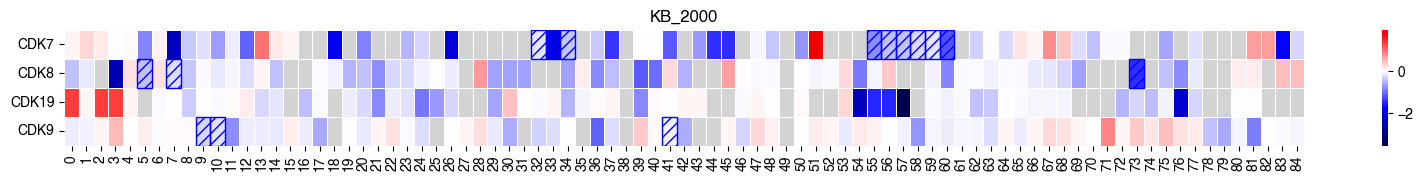

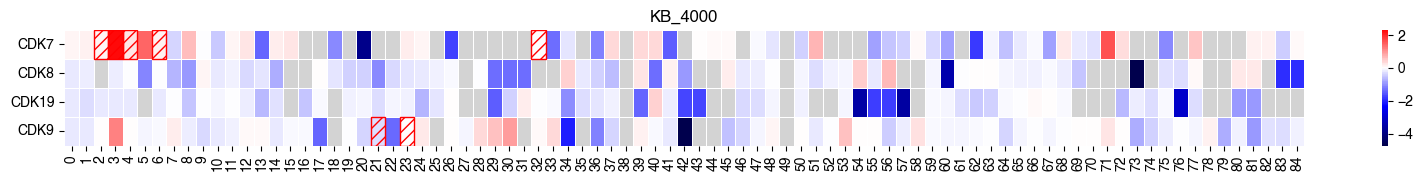

In [52]:
ABE_comp = pd.read_csv('../../screening_data/03_LFC_FDR_tables/proto_counts/DMSO_base/Compound_mutant_proto_DMSO_base.csv')
CBE_comp = ABE_comp
ABE_comp = ABE_comp[ABE_comp['base_RAW']>=min_base_counts]
CBE_comp = CBE_comp[CBE_comp['base_RAW']>=min_base_counts]

condition = 'KB_2000'
plotting_j = finger_plotv3(ABE_comp, CBE_comp, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

condition = 'KB_4000'
plotting_k = finger_plotv3(ABE_comp, CBE_comp, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

In [53]:
ABE_comp[ABE_comp['FDR_KB_2000']<.1][['gRNA_id', 'Gene', 'FDR_KB_2000', 'FDR_KB_4000', 'LFC_median_KB_2000', 'LFC_median_KB_4000', 'KB_4000_REP1','KB_4000_REP2','KB_4000_REP3','KB_2000_REP1','KB_2000_REP2','KB_2000_REP3']].sort_values(by='FDR_KB_4000')

,gRNA_id,Gene,FDR_KB_2000,FDR_KB_4000,LFC_median_KB_2000,LFC_median_KB_4000,KB_4000_REP1,KB_4000_REP2,KB_4000_REP3,KB_2000_REP1,KB_2000_REP2,KB_2000_REP3
73,gRNA_CDK7_targ_74,CDK7,0.000233,0.667949,-4.537722,-5.128252,-5.128252,-4.974972,-5.167428,-3.205170,-4.537722,-5.146777
1431,gRNA_CDK9_targ_1432,CDK9,0.067448,0.667949,-1.595883,-5.453209,-5.793183,-2.791247,-5.453209,-4.522993,-1.595883,0.551351
830,gRNA_CDK8_targ_831,CDK8,0.040408,0.873173,-1.441858,-4.695716,-6.013048,0.520697,-4.695716,-4.874379,-0.836575,-1.441858
1668,gRNA_CDK9_targ_1669,CDK9,0.073603,0.873173,-1.474879,-3.682542,-3.682542,-3.739087,-3.317010,-1.474879,-4.985926,0.912007
2515,gRNA_CDK8_intron_8554,CDK8,0.009808,0.873173,-4.161244,-5.238000,-5.238000,-0.500845,-5.239272,-4.932777,-4.161244,-1.553679
1600,gRNA_CDK9_targ_1601,CDK9,0.011559,0.873173,-2.667276,-5.182748,-5.749993,-5.182748,0.892015,-2.667276,-5.110253,-2.135782
1465,gRNA_CDK9_targ_1466,CDK9,0.009808,0.873173,-3.128794,-2.816944,-2.678316,-2.816944,-4.318812,-3.128794,-5.260505,-2.982930
569,gRNA_CDK8_targ_570,CDK8,0.022234,0.873173,-3.766446,-2.171721,-2.171721,-2.158511,-5.232398,-5.709404,-3.766446,-0.132599
909,gRNA_CDK8_targ_910,CDK8,0.026901,0.873173,-3.918232,-3.917457,-3.917457,-1.139186,-4.972886,3.113353,-5.100823,-3.918232
2130,gRNA_CDK19_targ_6664,CDK19,0.000829,0.875124,-4.427145,-3.372307,-3.619954,-0.134463,-3.372307,-4.870338,-4.427145,-0.831264


# Universal patterns

In [103]:
def top_hits(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition):

    #add coloring depending on if LFC >0 or LFC<0

    KLIFS2 = KLIFS.copy()

    #genes = ['CDK12', 'CDK13']

    for gene in genes:
        c = CBE_rg_dict[gene]
        a = ABE_rg_dict[gene]

        for i, val in KLIFS2.iterrows():
            nn = val[gene]
            try:
                subset_ABE = list(ABE_s2[ABE_s2['gRNA_id'].isin(a[i])][f'LFC_median_ABE_{condition}'])
                subset_CBE = list(CBE_s2[CBE_s2['gRNA_id'].isin(c[i])][f'LFC_median_CBE_{condition}'])

                #num_sig_ABE = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_ABE_{condition}']<FDR_cutoff)])
                #num_sig_CBE = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_CBE_{condition}']<FDR_cutoff)])

                num_sig_ABE_up = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_ABE_{condition}']<FDR_cutoff) & (ABE_s2[f'LFC_median_ABE_{condition}']>0)])
                num_sig_CBE_up = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_CBE_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_CBE_{condition}']>0)])
                num_sig_ABE_down = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_ABE_{condition}']<FDR_cutoff)& (ABE_s2[f'LFC_median_ABE_{condition}']<0)])
                num_sig_CBE_down = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_CBE_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_CBE_{condition}']<0)])
        
            except:
                subset_ABE = list(ABE_s2[ABE_s2['gRNA_id'].isin(a[i])][f'LFC_median_{condition}'])
                subset_CBE = list(CBE_s2[CBE_s2['gRNA_id'].isin(c[i])][f'LFC_median_{condition}'])

                num_sig_ABE_up = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_{condition}']<FDR_cutoff) & (ABE_s2[f'LFC_median_{condition}']>0)])
                num_sig_CBE_up = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_{condition}']>0)])
                num_sig_ABE_down = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_{condition}']<FDR_cutoff)& (ABE_s2[f'LFC_median_{condition}']<0)])
                num_sig_CBE_down = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_{condition}']<0)])


            total_sig_up = num_sig_ABE_up + num_sig_CBE_up
            total_sig_down = num_sig_ABE_down + num_sig_CBE_down
            comb1 = subset_ABE + subset_CBE

            KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_guides'] = len(comb1)
            KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_avg'] = np.average(comb1)
            KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_num_sig_up'] = total_sig_up
            KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_num_sig_down'] = total_sig_down
    
    #k2 = KLIFS2[['CDK12_guides', 'CDK12_avg', 'CDK13_guides', 'CDK13_avg']]

    return KLIFS2

In [ ]:
min_base_counts = 100
FDR_cutoff = 0.1
ABE_s2 = ABE_s2[ABE_s2['base_RAW']>=min_base_counts]
CBE_s2 = CBE_s2[CBE_s2['base_RAW']>=min_base_counts]

genes = ['CDK12', 'CDK13']
min_edit = 10

CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE2, SAV_CBE2, genes, min_edit)

condition = 'HQ461'

KLIFS_hq = top_hits(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
#fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)


condition = 'BSJ-4-116'
KLIFS_bsj = top_hits(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
#fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

condition = 'CDK12-IN-2'
KLIFS_cdk12 = top_hits(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
#fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)




In [112]:
up_hq = KLIFS_hq[['CDK12_num_sig_up',  'CDK13_num_sig_up']]
down_hq = KLIFS_hq[['CDK12_num_sig_down', 'CDK13_num_sig_down']]


up_bsj = KLIFS_bsj[['CDK12_num_sig_up',  'CDK13_num_sig_up']]
down_bsj = KLIFS_bsj[['CDK12_num_sig_down', 'CDK13_num_sig_down']]

up_cdk12 = KLIFS_cdk12[['CDK12_num_sig_up',  'CDK13_num_sig_up']]
down_cdk12 = KLIFS_cdk12[['CDK12_num_sig_down', 'CDK13_num_sig_down']]

<BarContainer object of 85 artists>

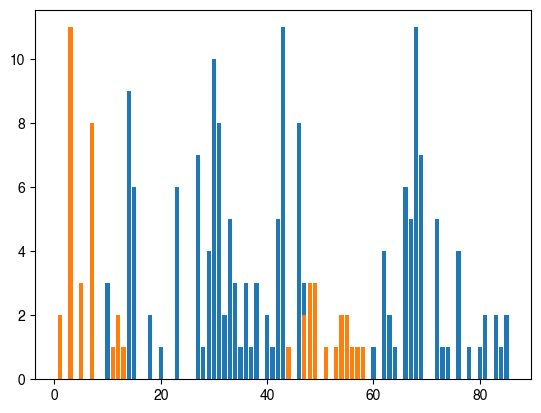

In [ ]:
up_hq = KLIFS_hq[['CDK12_num_sig_up',  'CDK13_num_sig_up']]
down_hq = KLIFS_hq[['CDK12_num_sig_down', 'CDK13_num_sig_down']]

tot_up = up_hq.sum(axis=1) + up_bsj.sum(axis=1) + up_cdk12.sum(axis=1)
tot_down = down_hq.sum(axis=1) + down_bsj.sum(axis=1) + down_cdk12.sum(axis=1)

plt.bar(range(1,86), tot_down)
plt.bar(range(1,86), tot_up)

In [358]:
min_base_counts = 100
FDR_cutoff = 0.1
ABE_s2 = ABE_s2[ABE_s2['base_RAW']>=min_base_counts]
CBE_s2 = CBE_s2[CBE_s2['base_RAW']>=min_base_counts]

genes = ['CDK12', 'CDK13']
min_edit = 10

CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE2, SAV_CBE2, genes, min_edit)

condition = 'HQ461'

conditions = ['HQ461', 'BSJ-4-116', 'CDK12-IN-2']

tot_up = np.zeros(85)
tot_down = np.zeros(85)

up_holder = []
down_holder = []


for condition in conditions:

    KLIFS_hq = top_hits(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

    up_hq = KLIFS_hq[['CDK12_num_sig_up',  'CDK13_num_sig_up']]
    down_hq = KLIFS_hq[['CDK12_num_sig_down', 'CDK13_num_sig_down']]

    tot_up += up_hq.sum(axis=1)
    tot_down += down_hq.sum(axis=1)

    up_holder.append(up_hq)
    down_holder.append(down_hq)
    

comb_up1 = sum(up_holder)
comb_down1 = sum(down_holder)



In [359]:
min_base_counts = 100
FDR_cutoff = 0.1
ABE_s1 = ABE_s1[ABE_s1['base_RAW']>=min_base_counts]
CBE_s1 = CBE_s1[CBE_s1['base_RAW']>=min_base_counts]

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']

CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE1, SAV_CBE1, genes, min_edit)


conditions = ['Senexin B_15000nM', 'Senexin B_2000nM', 'KI-CDK9d-32_100nM', 'KI-CDK9d-32_1000nM', 'KI-CDK9d-32N_1250nM', 'KI-CDK9d-32N_5000nM', 'SEL120_4000nM', 'KB-0742_1500nM']


tot_up2 = np.zeros(85)
tot_down2 = np.zeros(85)

up_holder = []
down_holder = []

for condition in conditions:

    KLIFS_hq = top_hits(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

    up_hq = KLIFS_hq[['CDK7_num_sig_up',  'CDK8_num_sig_up', 'CDK9_num_sig_up', 'CDK19_num_sig_up']]
    down_hq = KLIFS_hq[['CDK7_num_sig_down',  'CDK8_num_sig_down', 'CDK9_num_sig_down', 'CDK19_num_sig_down']]

    tot_up2 += up_hq.sum(axis=1)
    tot_down2 += down_hq.sum(axis=1)

    up_holder.append(up_hq)
    down_holder.append(down_hq)
    

comb_up2 = sum(up_holder)
comb_down2 = sum(down_holder)

In [360]:
#--------SY-------
ABE_sy = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/SY_5609_ABE_barcode_DMSO_base.csv')
CBE_sy = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/SY_5609_CBE_barcode_DMSO_base.csv')
ABE_sy = ABE_sy[ABE_sy['base_RAW']>=min_base_counts]
CBE_sy = CBE_sy[CBE_sy['base_RAW']>=min_base_counts]


CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE1, SAV_CBE1, genes, min_edit)


conditions = ['SY-5609_100nM', 'SY-5609_10nM']

tot_up3 = np.zeros(85)
tot_down3 = np.zeros(85)

up_holder = []
down_holder = []

for condition in conditions:

    KLIFS_hq = top_hits(ABE_sy, CBE_sy, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

    up_hq = KLIFS_hq[['CDK7_num_sig_up',  'CDK8_num_sig_up', 'CDK9_num_sig_up', 'CDK19_num_sig_up']]
    down_hq = KLIFS_hq[['CDK7_num_sig_down',  'CDK8_num_sig_down', 'CDK9_num_sig_down', 'CDK19_num_sig_down']]

    tot_up3 += up_hq.sum(axis=1)
    tot_down3 += down_hq.sum(axis=1)

    up_holder.append(up_hq)
    down_holder.append(down_hq)
    

comb_up3 = sum(up_holder)
comb_down3 = sum(down_holder)



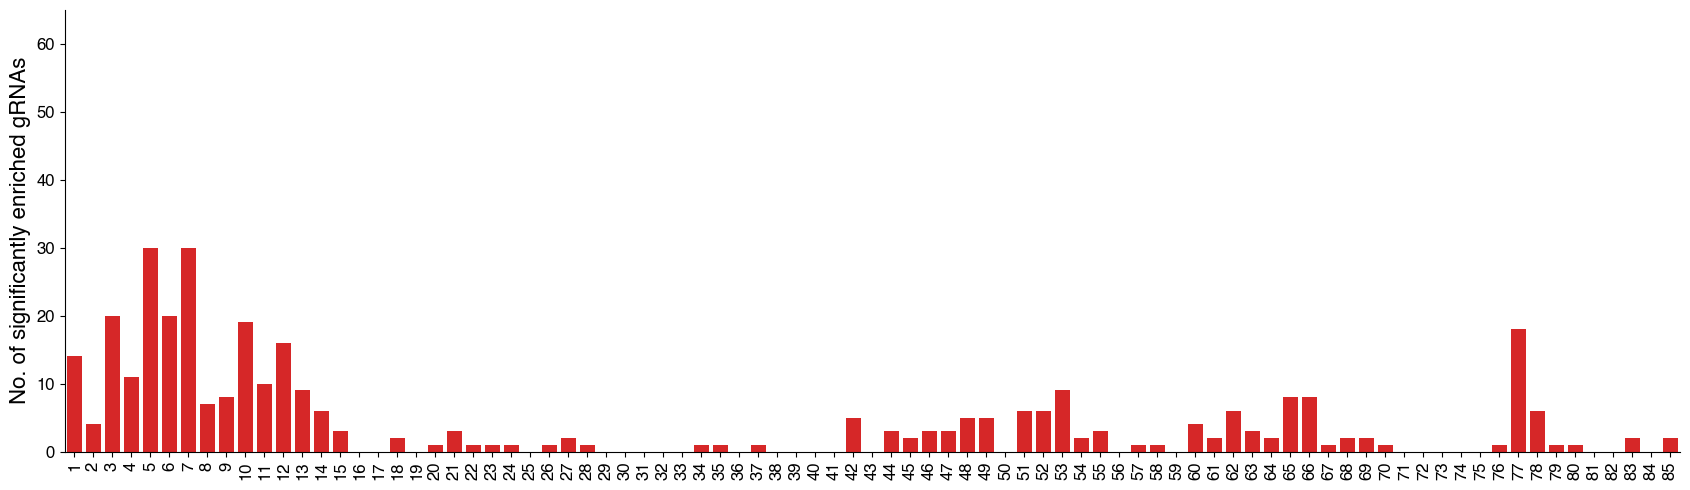

In [ ]:
fig, ax = plt.subplots(figsize=(17,5))

ax.bar(range(1,86), tot_up + tot_up2 + tot_up3, color='tab:red')
ax.set_xlim(0.5,85.5)
ax.set_ylabel('No. of significantly enriched gRNAs', fontsize=16)

ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90)
ax.set_ylim(0,65)
fig.tight_layout()

#fig.savefig('../../figures/sig_up_KLIFS_FDR_0.01.pdf', transparent=True)

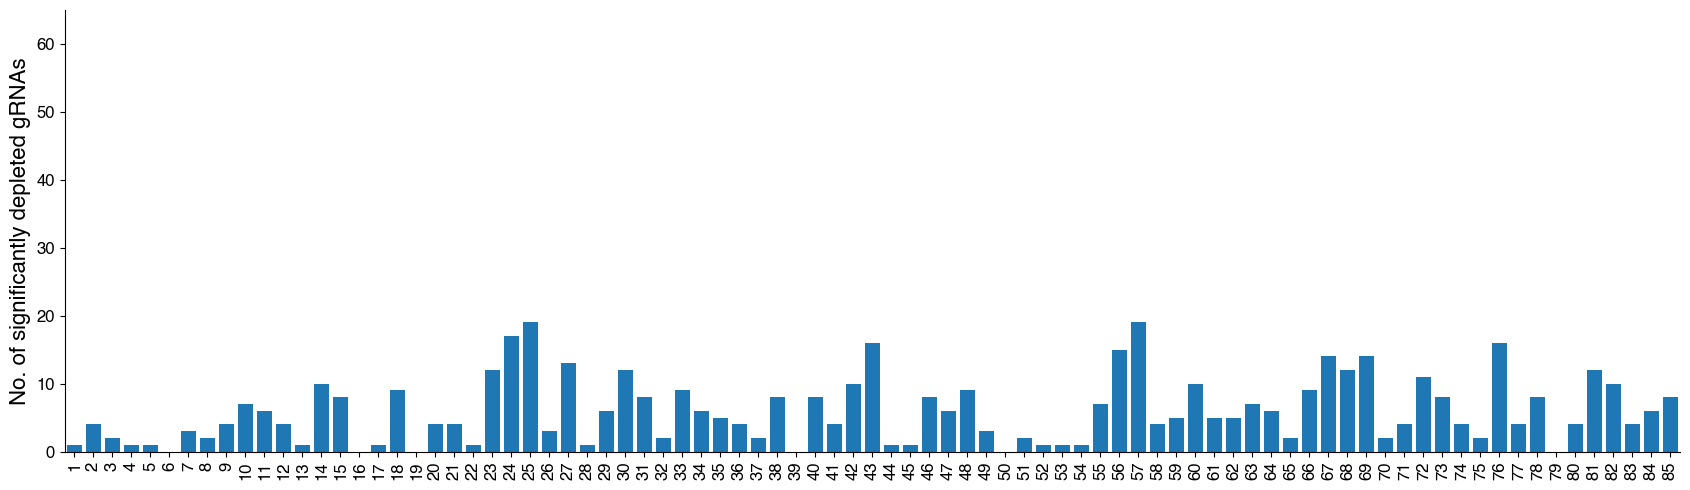

In [ ]:
fig, ax = plt.subplots(figsize=(17,5))

ax.bar(range(1,86), tot_down + tot_down2 + tot_down3, color='tab:blue')
ax.set_xlim(0.5,85.5)
ax.set_ylabel('No. of significantly depleted gRNAs', fontsize=16)

ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90)
ax.set_ylim(0,65)

fig.tight_layout()
#fig.savefig('../../figures/sig_down_KLIFS.pdf', transparent=True)

In [361]:
sub1 = comb_up2 + comb_up3

sub2 = comb_up1.rename(columns = {'CDK12_num_sig_up':'CDK12', 'CDK13_num_sig_up':'CDK13'})
sub1 = sub1.rename(columns = {'CDK7_num_sig_up':'CDK7', 'CDK8_num_sig_up':'CDK8', 'CDK9_num_sig_up':'CDK9', 'CDK19_num_sig_up':'CDK19'})

combined1 = pd.concat((sub1, sub2), axis=1)
combined1['KLIFS Index'] = list(range(1,86))
melted = pd.melt(combined1, id_vars='KLIFS Index')

melted

,KLIFS Index,variable,value
0,1,CDK7,10.0
1,2,CDK7,7.0
2,3,CDK7,19.0
3,4,CDK7,1.0
4,5,CDK7,4.0
...,...,...,...
505,81,CDK13,0.0
506,82,CDK13,0.0
507,83,CDK13,0.0
508,84,CDK13,0.0


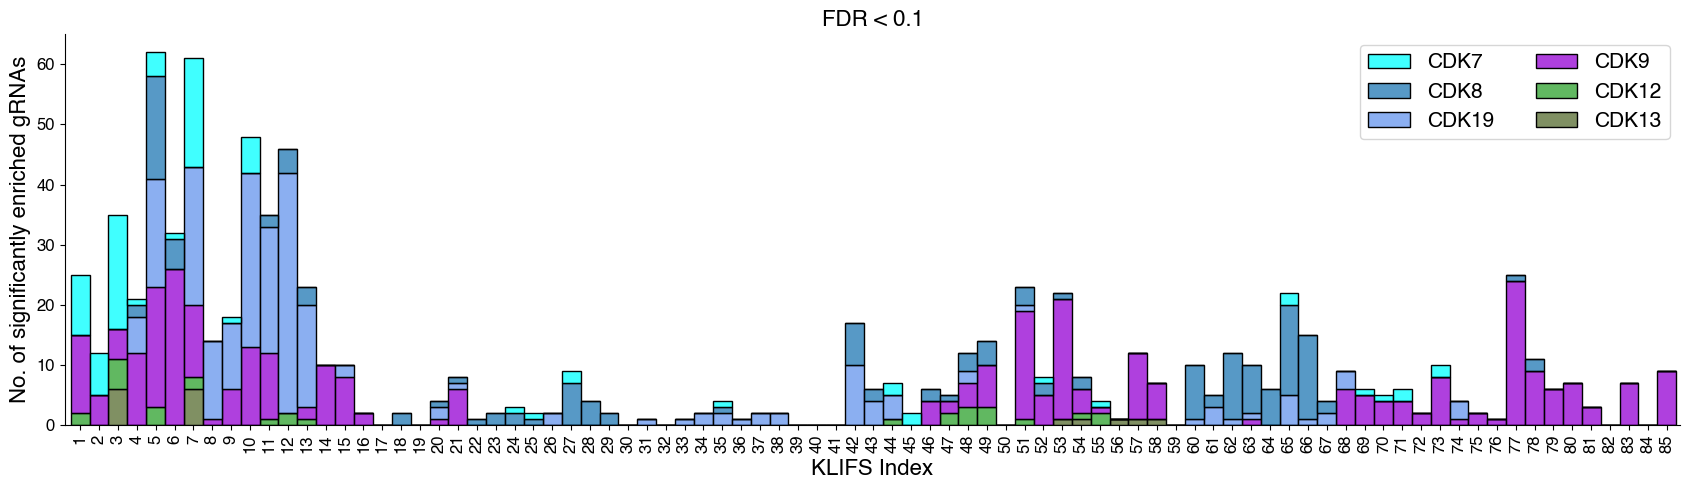

In [ ]:
fig, ax = plt.subplots(figsize=(17,5))

color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen'}

palette = list(color_dict.values())

hue_order = list(color_dict.keys())

sns.histplot(data = melted, bins = np.linspace(1,85,85), x = 'KLIFS Index',  ax=ax, weights='value', hue='variable', multiple='stack',discrete=True, legend=True, palette=palette, hue_order=hue_order)
#sns.stripplot(data = combined_klifs_edit, x = 'KLIFS Index', y='No. of gRNAs Targeting Codon', hue='Gene')


sns.move_legend(ax, "upper right", fontsize=15, ncols=2, title='')

ax.set_xlim(0.2,85.7)
ax.set_ylabel('No. of significantly enriched gRNAs', fontsize=16)
#ax.legend(fontsize=18)
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90)
ax.set_xlabel('KLIFS Index', fontsize=16)
#ax.set_title(f'Observed Resistance Mutations (OncoKB R1 & R2) n= {sum(melt_plot["count"])}', fontsize=16)
ax.set_ylim(0,65)
ax.set_title(f'FDR < {FDR_cutoff}', fontsize=16)
#sns.move_legend(ax, "center right")

fig.tight_layout()
#fig.savefig(f'../../figures/sig_up_FDR_{FDR_cutoff}_by_gene.pdf', transparent=True)

In [ ]:
sub1 = comb_down2 + comb_down3

sub2 = comb_down1.rename(columns = {'CDK12_num_sig_down':'CDK12', 'CDK13_num_sig_down':'CDK13'})
sub1 = sub1.rename(columns = {'CDK7_num_sig_down':'CDK7', 'CDK8_num_sig_down':'CDK8', 'CDK9_num_sig_down':'CDK9', 'CDK19_num_sig_down':'CDK19'})

combined1 = pd.concat((sub1, sub2), axis=1)
combined1['KLIFS Index'] = list(range(1,86))
melted = pd.melt(combined1, id_vars='KLIFS Index')

melted

,KLIFS Index,variable,value
0,1,CDK7,0.0
1,2,CDK7,2.0
2,3,CDK7,1.0
3,4,CDK7,0.0
4,5,CDK7,0.0
...,...,...,...
505,81,CDK13,0.0
506,82,CDK13,0.0
507,83,CDK13,2.0
508,84,CDK13,1.0


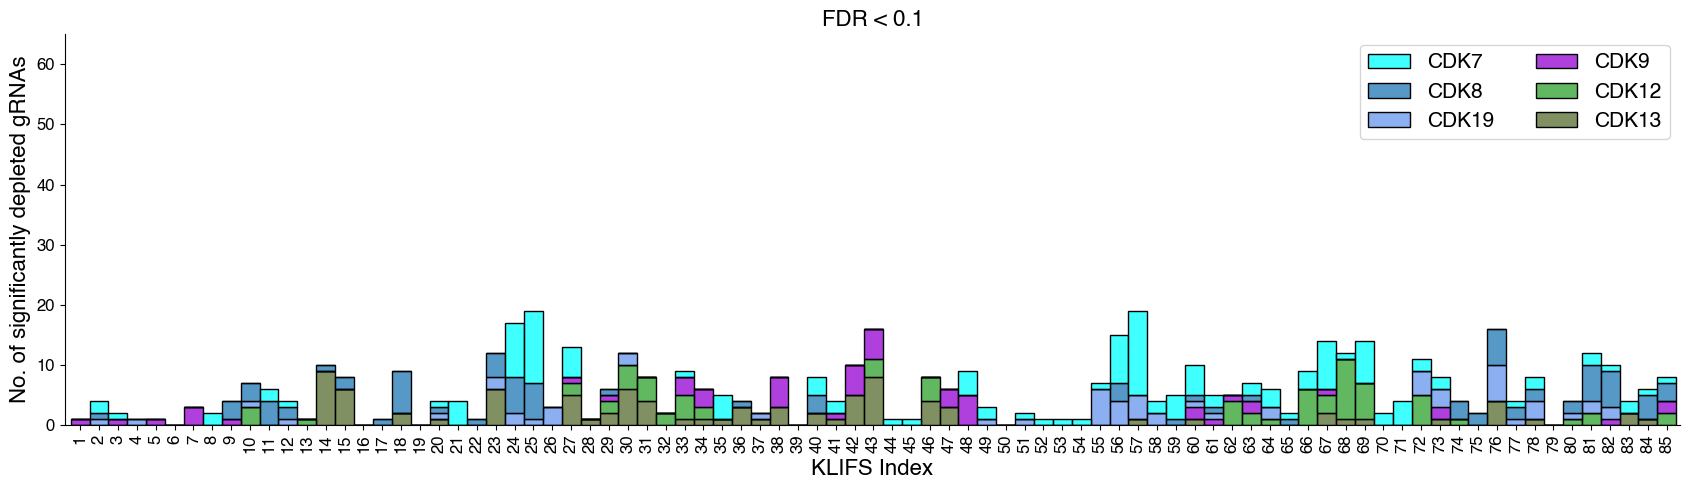

In [ ]:
fig, ax = plt.subplots(figsize=(17,5))

color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen'}

palette = list(color_dict.values())

hue_order = list(color_dict.keys())

sns.histplot(data = melted, bins = np.linspace(1,85,85), x = 'KLIFS Index',  ax=ax, weights='value', hue='variable', multiple='stack',discrete=True, legend=True, palette=palette, hue_order=hue_order)
#sns.stripplot(data = combined_klifs_edit, x = 'KLIFS Index', y='No. of gRNAs Targeting Codon', hue='Gene')


sns.move_legend(ax, "upper right", fontsize=15, ncols=2, title='')

ax.set_xlim(0.2,85.7)
ax.set_ylabel('No. of significantly depleted gRNAs', fontsize=16)
#ax.legend(fontsize=18)
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90)
ax.set_xlabel('KLIFS Index', fontsize=16)
ax.set_ylim(0,65)
ax.set_title(f'FDR < {FDR_cutoff}', fontsize=16)
#sns.move_legend(ax, "center right")

fig.tight_layout()
#fig.savefig(f'../../figures/sig_down_FDR_{FDR_cutoff}_by_gene.pdf', transparent=True)

In [367]:
#and for T0 as well!



min_base_counts = 100
FDR_cutoff = 0.1
ABE_s1 = ABE_s1_plasmid[ABE_s1_plasmid['base_RAW']>=min_base_counts]
CBE_s1 = CBE_s1_plasmid[CBE_s1_plasmid['base_RAW']>=min_base_counts]

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']
min_edit = 10

CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE1, SAV_CBE1, genes, min_edit)

condition = 'T0'
KLIFS_hq = top_hits(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

up_hq1 = KLIFS_hq[['CDK7_num_sig_up',  'CDK8_num_sig_up', 'CDK9_num_sig_up', 'CDK19_num_sig_up']]
down_hq1 = KLIFS_hq[['CDK7_num_sig_down',  'CDK8_num_sig_down', 'CDK9_num_sig_down', 'CDK19_num_sig_down']]

tot_up_s1 = up_hq1.sum(axis=1)
tot_down_s1 = down_hq1.sum(axis=1)

#-------and subpool1

min_base_counts = 100
FDR_cutoff = 0.1
ABE_s2 = ABE_s2_plasmid[ABE_s2_plasmid['base_RAW']>=min_base_counts]
CBE_s2 = CBE_s2_plasmid[CBE_s2_plasmid['base_RAW']>=min_base_counts]

genes = ['CDK12', 'CDK13']
min_edit = 10

CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE2, SAV_CBE2, genes, min_edit)

condition = 'T0'

KLIFS_hq = top_hits(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

up_hq2 = KLIFS_hq[['CDK12_num_sig_up',  'CDK13_num_sig_up']]
down_hq2 = KLIFS_hq[['CDK12_num_sig_down', 'CDK13_num_sig_down']]

tot_up_s2 = up_hq2.sum(axis=1)
tot_down_s2 = down_hq2.sum(axis=1)


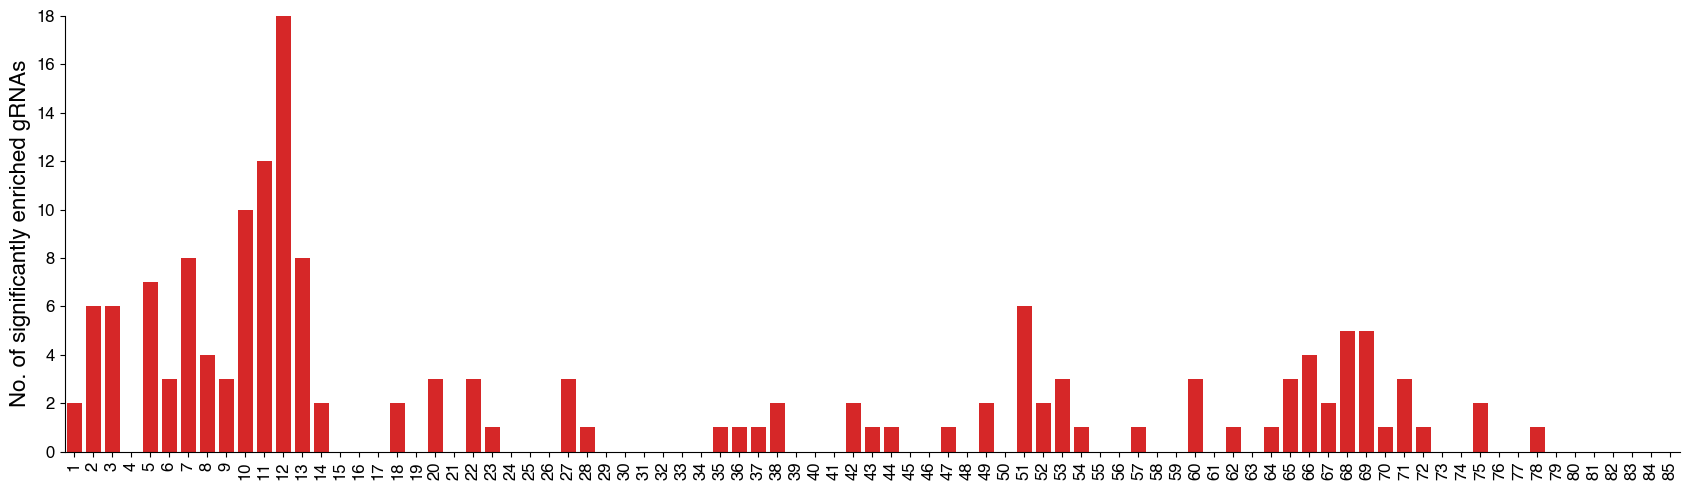

In [368]:
fig, ax = plt.subplots(figsize=(17,5))

ax.bar(range(1,86), tot_up_s2 + tot_up_s1, color='tab:red')
ax.set_xlim(0.5,85.5)
ax.set_ylabel('No. of significantly enriched gRNAs', fontsize=16)

ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90)
ax.set_ylim(0,18)
fig.tight_layout()
#fig.savefig('../../figures/sig_up_KLIFS_T0.pdf', transparent=True)

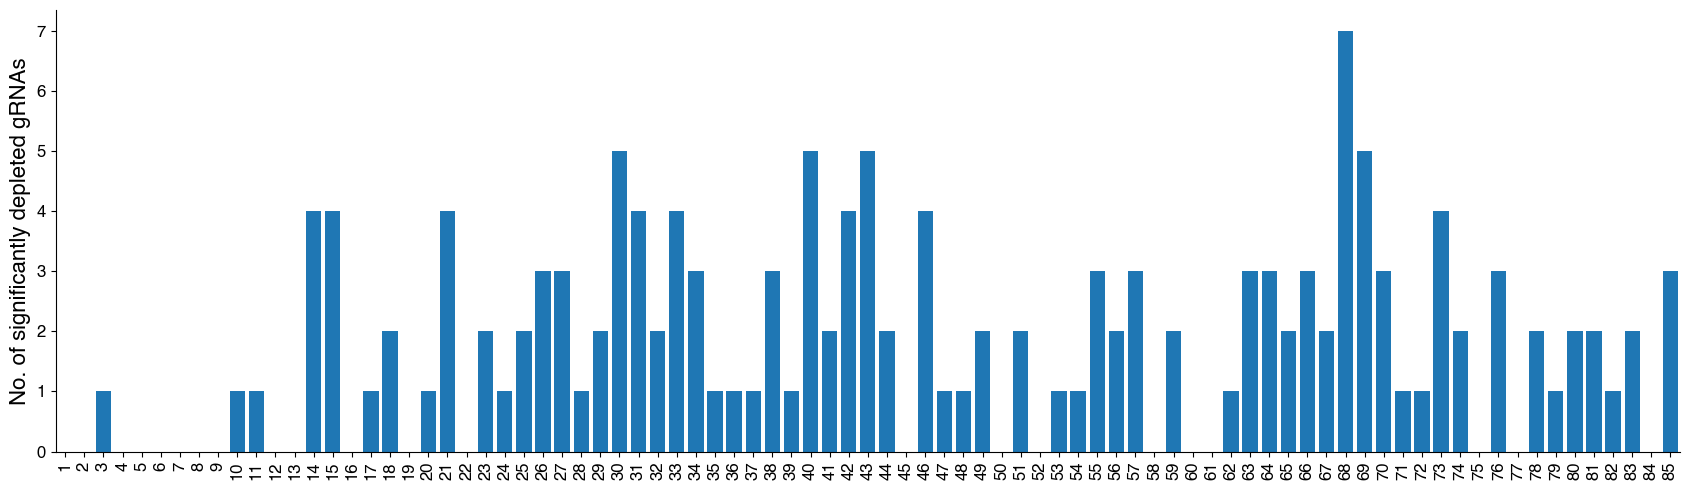

In [369]:
fig, ax = plt.subplots(figsize=(17,5))

ax.bar(range(1,86), tot_down_s1 +tot_down_s2 , color='tab:blue')
ax.set_xlim(0.5,85.5)
ax.set_ylabel('No. of significantly depleted gRNAs', fontsize=16)

ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90)

fig.tight_layout()
#fig.savefig('../../figures/sig_down_KLIFS_T0.pdf', transparent=True)

In [375]:

sub2 = up_hq2.rename(columns = {'CDK12_num_sig_up':'CDK12', 'CDK13_num_sig_up':'CDK13'})
sub1 = up_hq1.rename(columns = {'CDK7_num_sig_up':'CDK7', 'CDK8_num_sig_up':'CDK8', 'CDK9_num_sig_up':'CDK9', 'CDK19_num_sig_up':'CDK19'})

combined1 = pd.concat((sub1, sub2), axis=1)
combined1['KLIFS Index'] = list(range(1,86))
melted_UP = pd.melt(combined1, id_vars='KLIFS Index')



sub2 = down_hq2.rename(columns = {'CDK12_num_sig_down':'CDK12', 'CDK13_num_sig_down':'CDK13'})
sub1 = down_hq1.rename(columns = {'CDK7_num_sig_down':'CDK7', 'CDK8_num_sig_down':'CDK8', 'CDK9_num_sig_down':'CDK9', 'CDK19_num_sig_down':'CDK19'})

combined1 = pd.concat((sub1, sub2), axis=1)
combined1['KLIFS Index'] = list(range(1,86))
melted_DOWN = pd.melt(combined1, id_vars='KLIFS Index')

melted_DOWN

,KLIFS Index,variable,value
0,1,CDK7,0.0
1,2,CDK7,0.0
2,3,CDK7,0.0
3,4,CDK7,0.0
4,5,CDK7,0.0
...,...,...,...
505,81,CDK13,0.0
506,82,CDK13,0.0
507,83,CDK13,1.0
508,84,CDK13,0.0


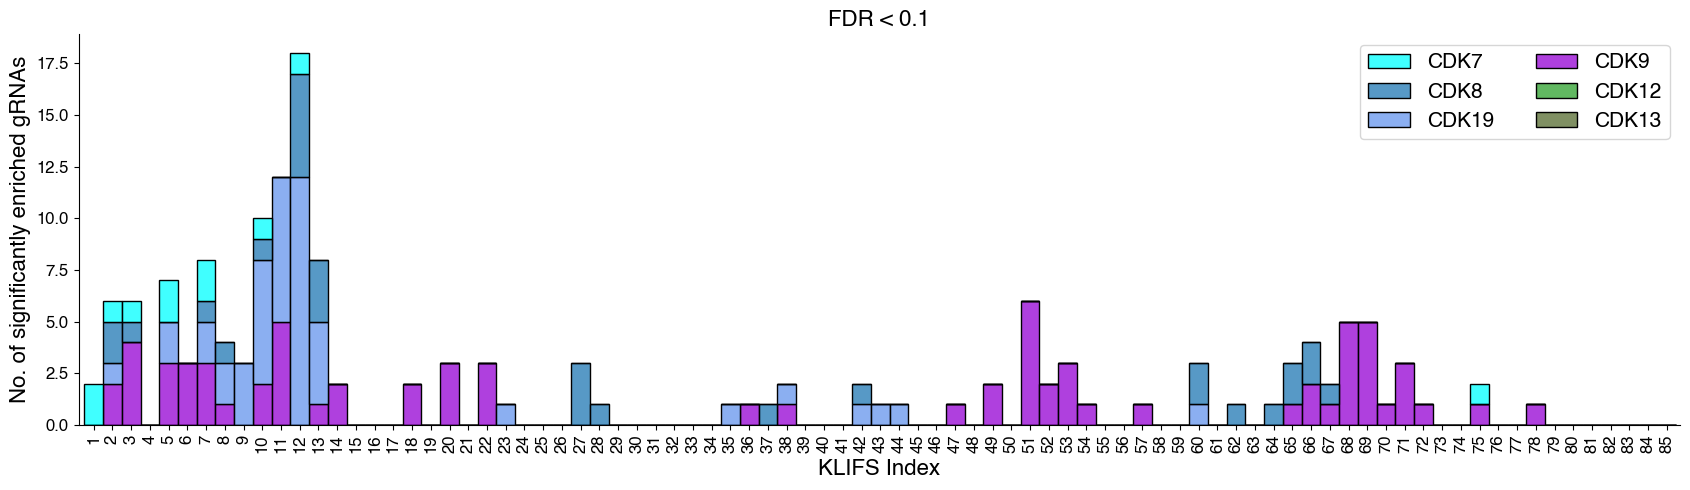

In [ ]:
fig, ax = plt.subplots(figsize=(17,5))

color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen'}

palette = list(color_dict.values())

hue_order = list(color_dict.keys())

sns.histplot(data = melted_UP, bins = np.linspace(1,85,85), x = 'KLIFS Index',  ax=ax, weights='value', hue='variable', multiple='stack',discrete=True, legend=True, palette=palette, hue_order=hue_order)
#sns.stripplot(data = combined_klifs_edit, x = 'KLIFS Index', y='No. of gRNAs Targeting Codon', hue='Gene')


sns.move_legend(ax, "upper right", fontsize=15, ncols=2, title='')

ax.set_xlim(0.2,85.7)
ax.set_ylabel('No. of significantly enriched gRNAs', fontsize=16)
#ax.legend(fontsize=18)
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90)
ax.set_xlabel('KLIFS Index', fontsize=16)
#ax.set_title(f'Observed Resistance Mutations (OncoKB R1 & R2) n= {sum(melt_plot["count"])}', fontsize=16)
ax.set_title(f'FDR < {FDR_cutoff}', fontsize=16)
#sns.move_legend(ax, "center right")

fig.tight_layout()
#fig.savefig(f'../../figures/sig_up_FDR_{FDR_cutoff}_by_gene_T0.pdf', transparent=True)

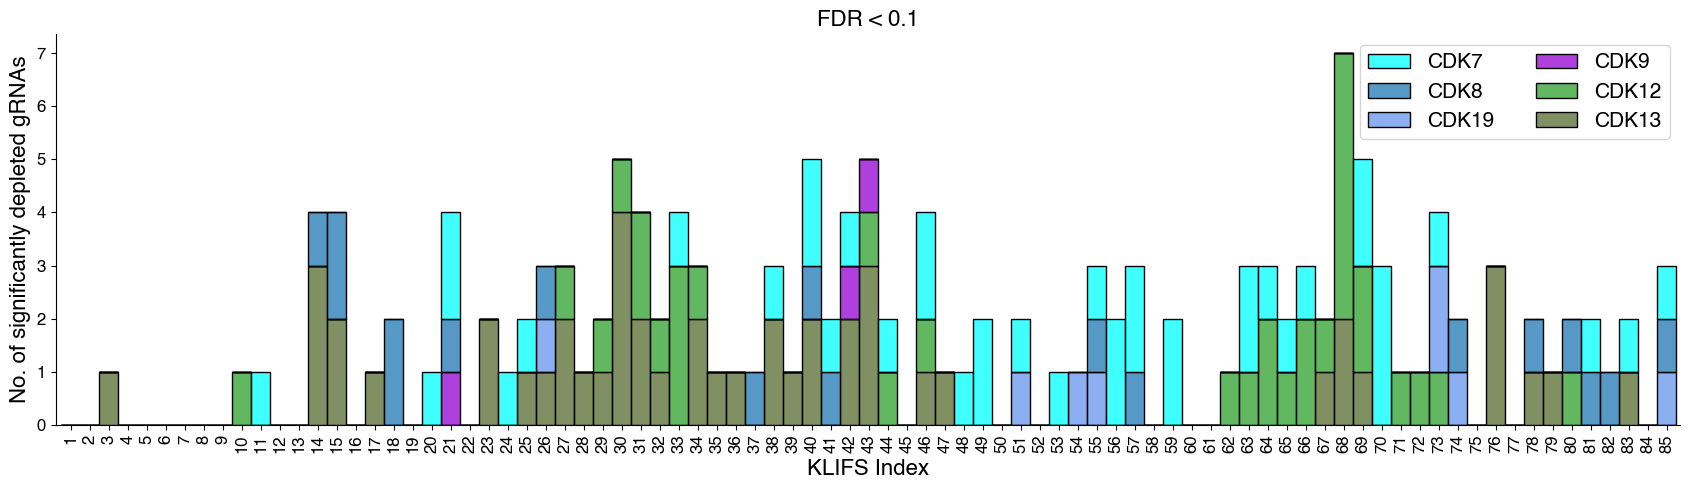

In [ ]:
fig, ax = plt.subplots(figsize=(17,5))

color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen'}

palette = list(color_dict.values())

hue_order = list(color_dict.keys())

sns.histplot(data = melted_DOWN, bins = np.linspace(1,85,85), x = 'KLIFS Index',  ax=ax, weights='value', hue='variable', multiple='stack',discrete=True, legend=True, palette=palette, hue_order=hue_order)
#sns.stripplot(data = combined_klifs_edit, x = 'KLIFS Index', y='No. of gRNAs Targeting Codon', hue='Gene')


sns.move_legend(ax, "upper right", fontsize=15, ncols=2, title='')

ax.set_xlim(0.2,85.7)
ax.set_ylabel('No. of significantly depleted gRNAs', fontsize=16)
#ax.legend(fontsize=18)
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90)
ax.set_xlabel('KLIFS Index', fontsize=16)
#ax.set_title(f'Observed Resistance Mutations (OncoKB R1 & R2) n= {sum(melt_plot["count"])}', fontsize=16)
ax.set_title(f'FDR < {FDR_cutoff}', fontsize=16)
#sns.move_legend(ax, "center right")

fig.tight_layout()
#fig.savefig(f'../../figures/sig_down_FDR_{FDR_cutoff}_by_gene_T0.pdf', transparent=True)

In [250]:
min_edit = 50

genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19']
CBE_rg_dict1, ABE_rg_dict1 = rg_dict_gen(SAV_ABE1, SAV_CBE1, genes, min_edit)

genes = ['CDK12', 'CDK13']
CBE_rg_dict2, ABE_rg_dict2 = rg_dict_gen(SAV_ABE2, SAV_CBE2, genes, min_edit)



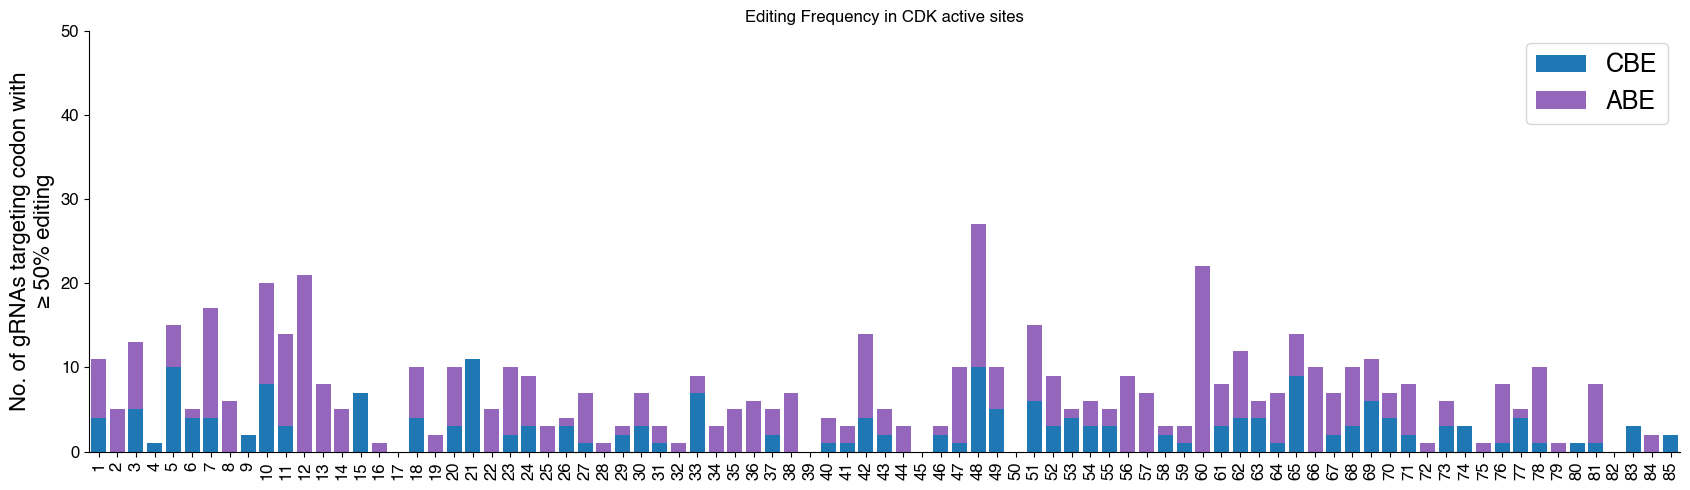

In [255]:

gene = []
cbe_h = []
abe_h = []


for i in CBE_rg_dict1.keys():
    gene.append(i)
    cc = [len(i) for i in CBE_rg_dict1[i]]
    aa = [len(i) for i in ABE_rg_dict1[i]]
    cbe_h.append(cc)
    abe_h.append(aa)


for i in CBE_rg_dict2.keys():
    gene.append(i)
    cc = [len(i) for i in CBE_rg_dict2[i]]
    aa = [len(i) for i in ABE_rg_dict2[i]]
    cbe_h.append(cc)
    abe_h.append(aa)

#-------plotting
num_muts_cbe = pd.DataFrame(dict(zip(gene, cbe_h)))
num_muts_abe = pd.DataFrame(dict(zip(gene, abe_h)))

a_total = num_muts_abe.sum(axis=1)
c_total = num_muts_cbe.sum(axis=1)

fig, ax = plt.subplots(figsize=(17,5))

ax.bar(range(1,86), c_total , color='tab:blue', label='CBE')
ax.bar(range(1,86), a_total, bottom = c_total , color='tab:purple', label='ABE')

ax.set_xlim(0.5,85.5)
ax.set_ylabel(f'No. of gRNAs targeting codon with\n≥ {min_edit}% editing', fontsize=16)

ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90)
ax.set_ylim(0,50)
ax.legend(fontsize=18)
ax.set_title('Editing Frequency in CDK active sites')
fig.tight_layout()
fig.savefig(f'../../figures/KLIFS_{min_edit}_editing.pdf', transparent=True)

In [253]:
num_muts_abe['KLIFS Index'] = list(range(1,86))
num_muts_cbe['KLIFS Index'] = list(range(1,86))

num_muts_abe = num_muts_abe.melt(id_vars = ('KLIFS Index')).rename(columns={'variable':'Gene', 'value':'No. of gRNAs Targeting Codon'})
num_muts_cbe = num_muts_cbe.melt(id_vars = ('KLIFS Index')).rename(columns={'variable':'Gene', 'value':'No. of gRNAs Targeting Codon'})

num_muts_abe['Editor'] = 'ABE'
num_muts_cbe['Editor'] = 'CBE'

combined_klifs_edit = pd.concat((num_muts_abe, num_muts_cbe))



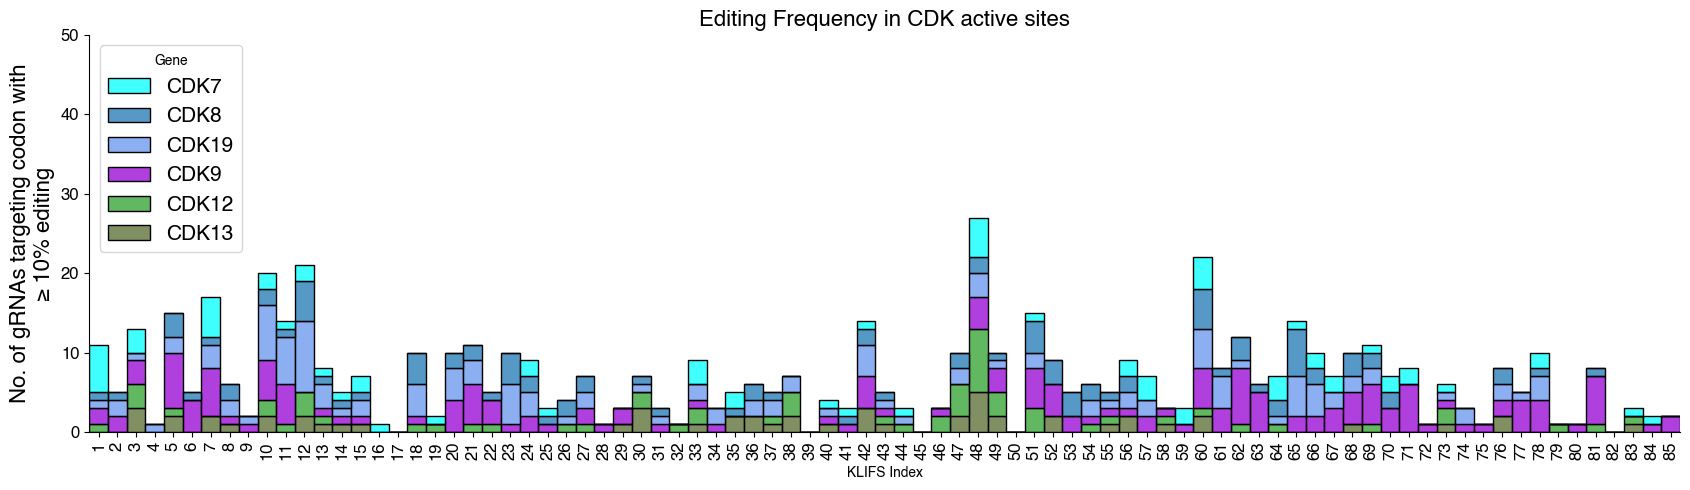

In [327]:
#ax = sns.histplot(co, x='Date', hue='Type', weights='Value', multiple='stack')

color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen'}

palette = list(color_dict.values())

hue_order = list(color_dict.keys())



fig, ax = plt.subplots(figsize=(17,5))

sns.histplot(data = combined_klifs_edit, bins = np.linspace(1,85,85), x = 'KLIFS Index',  ax=ax, weights='No. of gRNAs Targeting Codon', hue='Gene', multiple='stack', hue_order = hue_order, palette=palette, discrete=True, legend=True)
#sns.stripplot(data = combined_klifs_edit, x = 'KLIFS Index', y='No. of gRNAs Targeting Codon', hue='Gene')

ax.set_xlim(0.5,85.5)
ax.set_ylabel(f'No. of gRNAs targeting codon with\n≥ {min_edit}% editing', fontsize=16)
ax.set_ylim(0,50)

sns.move_legend(ax, "upper left", fontsize=15)

ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90)
ax.set_title('Editing Frequency in CDK active sites', fontsize=16)
fig.tight_layout()
#fig.savefig(f'../../figures/editing_by_cdk_flifs_{min_edit}.pdf', transparent=True)


In [326]:
combined_klifs_edit

,KLIFS Index,Gene,No. of gRNAs Targeting Codon,Editor
0,1,CDK7,5,ABE
1,2,CDK7,0,ABE
2,3,CDK7,0,ABE
3,4,CDK7,0,ABE
4,5,CDK7,0,ABE
...,...,...,...,...
505,81,CDK13,0,CBE
506,82,CDK13,0,CBE
507,83,CDK13,1,CBE
508,84,CDK13,0,CBE
